In [1]:
# from huggingface_hub import hf_hub_download
# dataset1 = hf_hub_download("tacofoundation/CloudSEN12", "cloudsen12-l1c.0000.part.taco", repo_type="dataset", local_dir="home/src/datasets/cloudsen12/")
# dataset2 = hf_hub_download("tacofoundation/CloudSEN12", "cloudsen12-l1c.0001.part.taco", repo_type="dataset", local_dir="home/src/datasets/cloudsen12/")
# dataset3 = hf_hub_download("tacofoundation/CloudSEN12", "cloudsen12-l1c.0002.part.taco", repo_type="dataset", local_dir="home/src/datasets/cloudsen12/")
# dataset4 = hf_hub_download("tacofoundation/CloudSEN12", "cloudsen12-l1c.0003.part.taco", repo_type="dataset", local_dir="home/src/datasets/cloudsen12/")
# dataset5 = hf_hub_download("tacofoundation/CloudSEN12", "cloudsen12-l1c.0004.part.taco", repo_type="dataset", local_dir="home/src/datasets/cloudsen12/")

In [10]:
import tacoreader
import rasterio as rio
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm 
import pandas as pd
from prettytable import PrettyTable

In [11]:
# Открываем датасет

dataset = tacoreader.load(["datasets/cloudsen12/cloudsen12-l1c.0000.part.taco", 
                           "datasets/cloudsen12/cloudsen12-l1c.0001.part.taco",
                           "datasets/cloudsen12/cloudsen12-l1c.0002.part.taco",
                           "datasets/cloudsen12/cloudsen12-l1c.0003.part.taco",
                           "datasets/cloudsen12/cloudsen12-l1c.0004.part.taco"])

### Общая информация

In [12]:
print(f"Количество элементов датасета: {len(dataset)}")

Количество элементов датасета: 50247


In [13]:
# Читаем sample

sample_idx = 556
image_path = dataset.read(sample_idx).read(0)
mask_path = dataset.read(sample_idx).read(1)

In [14]:
# Извлекаем изображения

with rio.open(image_path) as src, rio.open(mask_path) as dst:
    image = src.read([4, 3, 2, 8],window=rio.windows.Window(0, 0, 512, 512))
    mask = dst.read(window=rio.windows.Window(0, 0, 512, 512))
    print(f"Элемент датасет содержит {src.count} каналов,\nа именно: {src.descriptions}")

Элемент датасет содержит 13 каналов,
а именно: ('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B10', 'B11', 'B12')


In [15]:
# Далее берем изображение, содержащее 4 канала R, G, B, NIR и изображение с маской.

In [16]:
print(f"Размер изображения: {image.shape}")
print(f"Размер маски: {mask.shape}")

Размер изображения: (4, 512, 512)
Размер маски: (1, 512, 512)


In [ ]:
print("Маска представлена 4 значениями:")

masks_content = PrettyTable()

masks_content.field_names = ["Mask Code", "Feature"]

masks_content.add_row([0, "Clear"])
masks_content.add_row([1, "Thick Cloud"])
masks_content.add_row([2, "Thin Cloud"])
masks_content.add_row([3, "Cloud Shadow"])

print(masks_content)

Маска представлена 7 значениями:
+-----------+--------------+
| Mask Code |   Feature    |
+-----------+--------------+
|     0     |    Clear     |
|     1     | Thick Cloud  |
|     2     |  Thin Cloud  |
|     3     | Cloud Shadow |
+-----------+--------------+


### Визуализация

In [19]:
def visualize(r, g, b, nir, mask):
    
    plt.figure(figsize=(30, 7))

    plt.subplot(1, 5, 1)
    plt.imshow(r, cmap='Reds')
    plt.title("Red band image")
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.imshow(g, cmap='Greens')
    plt.title("Green band image")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.imshow(b, cmap='Blues')
    plt.title("Blue band image")
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.imshow(nir, cmap='plasma')
    plt.title("NIR band image")
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.imshow(mask, cmap='gray')
    plt.title("Original mask")
    plt.axis("off")

    plt.show()

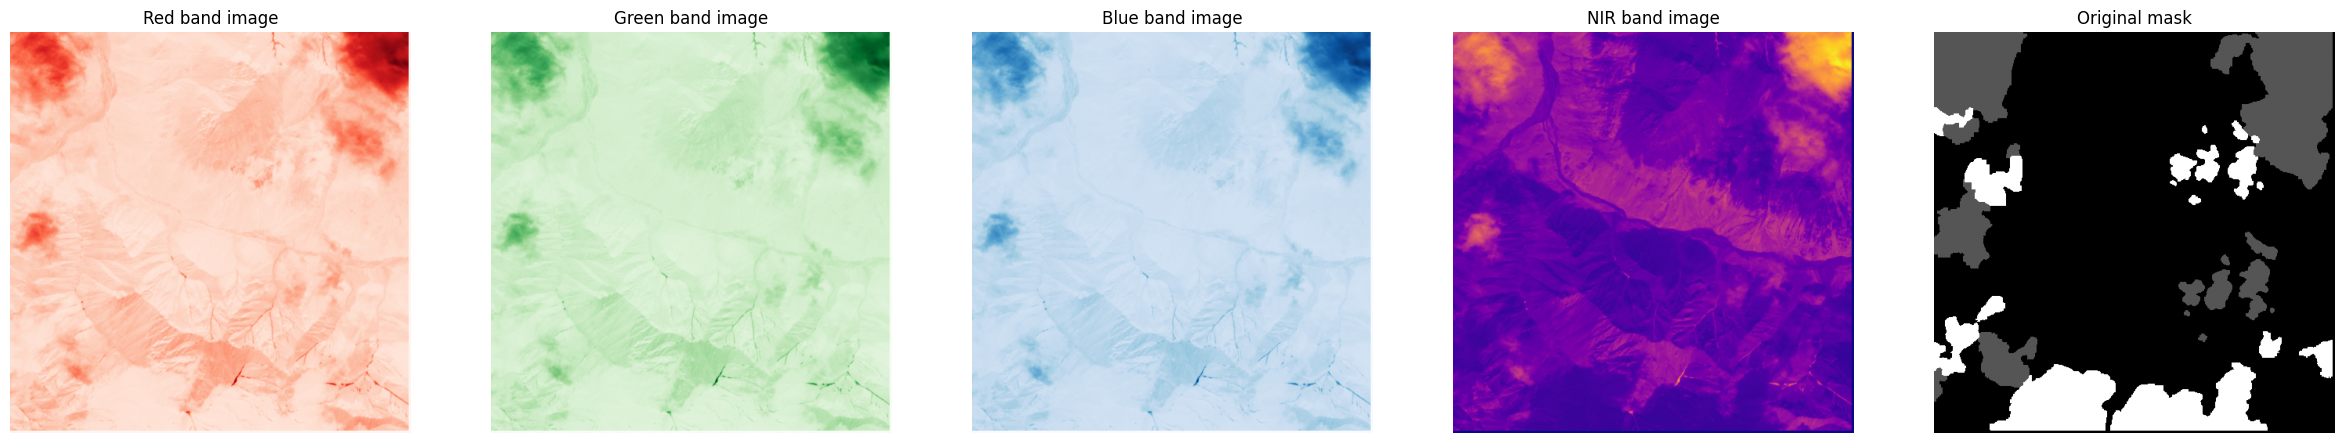

In [20]:
# Пример элемента датасета

visualize(image[0], image[1], image[2], image[3], mask.squeeze())

### Анализ dataset

In [21]:
# Пример датасета

dataset.head()

,internal:subfile,tortilla:id,tortilla:file_format,tortilla:data_split,tortilla:offset,tortilla:length,stac:crs,stac:geotransform,stac:raster_shape,stac:time_start,...,equi_zone,label_type,s2_id,real_proj_shape,s2_mean_solar_azimuth_angle,s2_mean_solar_zenith_angle,thick_percentage,thin_percentage,cloud_shadow_percentage,clear_percentage
40298,"/vsisubfile/10460113754_1437347,datasets/cloud...",ROI_00001__20190212T142031_20190212T143214_T19FDF,TORTILLA,test,10460113754,1437347,EPSG:32719,"[440030.0, 10.0, 0.0, 4573910.0, 0.0, -10.0]","[512, 512]",1.549982e+09,...,SA,high,S2A_MSIL1C_20190212T142031_N0207_R010_T19FDF_2...,509,50.052448,44.778064,0,32,0,68
40299,"/vsisubfile/10461551101_1288233,datasets/cloud...",ROI_00001__20190304T142031_20190304T142654_T19FDF,TORTILLA,test,10461551101,1288233,EPSG:32719,"[440030.0, 10.0, 0.0, 4573910.0, 0.0, -10.0]","[512, 512]",1.551710e+09,...,SA,high,S2A_MSIL1C_20190304T142031_N0207_R010_T19FDF_2...,509,44.599861,38.733580,15,0,81,4
40300,"/vsisubfile/10462839334_1437179,datasets/cloud...",ROI_00001__20190316T141049_20190316T142437_T19FDF,TORTILLA,test,10462839334,1437179,EPSG:32719,"[440030.0, 10.0, 0.0, 4573910.0, 0.0, -10.0]","[512, 512]",1.552746e+09,...,SA,high,S2B_MSIL1C_20190316T141049_N0207_R110_T19FDF_2...,509,43.830052,33.774744,54,0,18,28
40301,"/vsisubfile/10464276513_1504849,datasets/cloud...",ROI_00001__20190525T141059_20190525T142053_T19FDF,TORTILLA,test,10464276513,1504849,EPSG:32719,"[440030.0, 10.0, 0.0, 4573910.0, 0.0, -10.0]","[512, 512]",1.558794e+09,...,SA,high,S2B_MSIL1C_20190525T141059_N0207_R110_T19FDF_2...,509,30.856044,14.175443,25,23,10,42
40302,"/vsisubfile/10465781362_1501969,datasets/cloud...",ROI_00001__20200308T141731_20200308T143551_T19FDF,TORTILLA,test,10465781362,1501969,EPSG:32719,"[440030.0, 10.0, 0.0, 4573910.0, 0.0, -10.0]","[512, 512]",1.583678e+09,...,SA,high,S2A_MSIL1C_20200308T141731_N0209_R010_T19FDF_2...,509,43.215801,37.216397,0,0,0,100


In [22]:
# Смотрим, какие параметры есть в датасете

print(f"Колонки датасета:\n{dataset.columns}")

Колонки датасета:
Index(['internal:subfile', 'tortilla:id', 'tortilla:file_format',
       'tortilla:data_split', 'tortilla:offset', 'tortilla:length', 'stac:crs',
       'stac:geotransform', 'stac:raster_shape', 'stac:time_start',
       'stac:time_end', 'stac:centroid', 'rai:ele', 'rai:cisi', 'rai:gdp',
       'rai:hdi', 'rai:gmi', 'rai:pop', 'rai:admin0', 'rai:admin1',
       'rai:admin2', 'roi_id', 'old_roi_id', 'equi_id', 'equi_zone',
       'label_type', 's2_id', 'real_proj_shape', 's2_mean_solar_azimuth_angle',
       's2_mean_solar_zenith_angle', 'thick_percentage', 'thin_percentage',
       'cloud_shadow_percentage', 'clear_percentage'],
      dtype='object')


In [23]:
# Создаем датасет с необходимыми ключами

df = dataset[['tortilla:data_split', 'stac:raster_shape', 'real_proj_shape', 'thick_percentage', 'thin_percentage','cloud_shadow_percentage', 'clear_percentage']]
df

,tortilla:data_split,stac:raster_shape,real_proj_shape,thick_percentage,thin_percentage,cloud_shadow_percentage,clear_percentage
40298,test,"[512, 512]",509,0,32,0,68
40299,test,"[512, 512]",509,15,0,81,4
40300,test,"[512, 512]",509,54,0,18,28
40301,test,"[512, 512]",509,25,23,10,42
40302,test,"[512, 512]",509,0,0,0,100
...,...,...,...,...,...,...,...
38837,train,"[2048, 2048]",2000,71,0,4,25
50153,train,"[2048, 2048]",2000,76,0,0,24
39193,validation,"[2048, 2048]",2000,77,0,5,18
38938,train,"[2048, 2048]",2000,67,0,17,16


In [24]:
print(f"Разбиение датасета:\n\n{df['tortilla:data_split'].value_counts()}")

Разбиение датасета:

tortilla:data_split
train         47360
test           1715
validation     1172
Name: count, dtype: int64


In [25]:
print(f"Размеры проекций снимков:\n\n{df['real_proj_shape'].value_counts()}")

Размеры проекций снимков:

real_proj_shape
509     49400
2000      847
Name: count, dtype: int64


In [26]:
size_counting = {'512_512':0, '2048_2048':0}
s = set()
for elem in df['stac:raster_shape']:
    if elem[0] == 512:
        size_counting['512_512'] += 1
    elif elem[0] == 2048:
        size_counting['2048_2048'] += 1
    else:
        print('Есть другие элементы!')

print(f"Размеры снимков:\n\n512x512: {size_counting['512_512']}\n2048x2048: {size_counting['2048_2048']}")

Размеры снимков:

512x512: 49400
2048x2048: 847


In [ ]:
# Посчитаем среднее содержание облаков на снимках

print(f"Средние значения объекта, которыми занято изображение\n\n"
      f"Clear:  {round(df['clear_percentage'].mean(), 2)}%\n"
      f"Thin:   {round(df['thin_percentage'].mean(), 2)}%\n"
      f"Thick:  {round(df['thick_percentage'].mean(), 2)}%\n"
      f"Shadow: {round(df['cloud_shadow_percentage'].mean(), 2)}%\n")

Средние значения объекта, которыми занято изображение

Clear:  55.72%
Thin:   8.66%
Thick:  27.54%
Shadow: 8.08%



### Анализ изображений

In [28]:
images = []
masks = []
means = []
stds = []

null_count = 0 # проверка на пустоту
occupancy = [] # какая площадь занята ненулевыми пикселями
average_image_r = img = np.zeros((512, 512), dtype=np.float32)
average_image_g = img = np.zeros((512, 512), dtype=np.float32)
average_image_b = img = np.zeros((512, 512), dtype=np.float32)
average_image_nir = img = np.zeros((512, 512), dtype=np.float32)

for idx in tqdm(range(len(dataset)), desc="Обработка изображений"):
    image_path = dataset.read(sample_idx).read(0)
    mask_path = dataset.read(sample_idx).read(1)

    with rio.open(image_path) as src, rio.open(mask_path) as dst:
        image = src.read([4, 3, 2, 8], window=rio.windows.Window(0, 0, 512, 512))
        mask = dst.read(window=rio.windows.Window(0, 0, 512, 512))
        
    if image.max() == 0:
        null_count += 1
    
    nonzero_mask = np.any(image != 0, axis=0)
    occupied_pixels = np.sum(nonzero_mask)
    total_pixels = image.shape[1] * image.shape[2]
    fraction = occupied_pixels / total_pixels
    occupancy.append(fraction)

    means.append(image.mean(axis=(1,2)))
    stds.append(image.std(axis=(1,2)))

    average_image_r += image[0]
    average_image_g += image[1]
    average_image_b += image[2]
    average_image_nir += image[3]


occupancy = np.array(occupancy)
means = np.array(means)
stds = np.array(stds)

average_image_r /= len(dataset)
average_image_g /= len(dataset)
average_image_b /= len(dataset)
average_image_nir /= len(dataset)


Обработка изображений: 100%|██████████| 50247/50247 [21:00<00:00, 39.86it/s] 


In [29]:
print(f"Пустых снимков: {null_count}")
print(f"Средний занятость изображения ненулевыми пикселями: {round(occupancy.mean() * 100, 2)}%")
print("Средние значения по каналам (r, g, b, nir):\n", list(map(round, means.mean(axis=0))))
print("Стандартные отклонения по каналам (r, g, b, nir):\n", list(map(round, stds.mean(axis=0))))

Пустых снимков: 0
Средний занятость изображения ненулевыми пикселями: 98.83%
Средние значения по каналам (r, g, b, nir):
 [1445, 1517, 1737, 1777]
Стандартные отклонения по каналам (r, g, b, nir):
 [820, 708, 696, 1005]


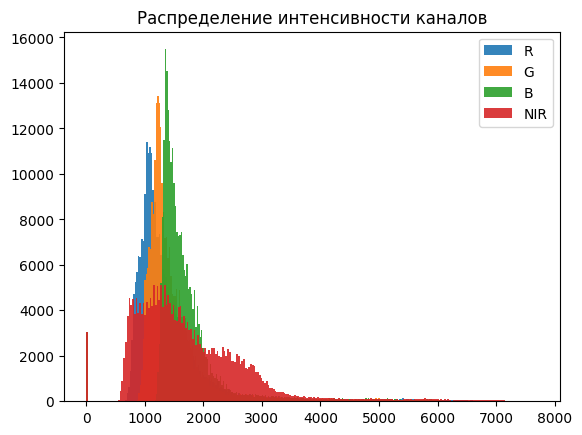

In [30]:
# Гистограмма распределения цветов для каждого канала (R, G, B, NIR)

average_image = np.stack([average_image_r, average_image_g, average_image_b, average_image_nir], axis=0)

for i, col in enumerate(['R', 'G', 'B', 'NIR']):
    plt.hist(average_image[i, ...].ravel(), bins=256, alpha=0.9, label=col)
plt.legend(); plt.title("Распределение интенсивности каналов")
plt.show()

### Итог

In [31]:
# Итоговый отчет

df = pd.DataFrame({
    'Метрика': ['Всего изображений', 'Формат изображений', 'Размер изображения', 'Средняя доля облаков', 'Пустых масок', 'Тип масок'],
    'Значение': [len(dataset), 'GTiff', '512x512, 2048x2048', f'~36%', f'{null_count}', '4 класса']
})

df

,Метрика,Значение
0,Всего изображений,50247
1,Формат изображений,GTiff
2,Размер изображения,"512x512, 2048x2048"
3,Средняя доля облаков,~36%
4,Пустых масок,0
5,Тип масок,4 класса
